# Thermosensibilité de la consommation électrique française

Objectif : quel est le poids de la température dans la consommation ?

In [1]:
import pandas as pd

In [2]:
eco2mix=pd.read_csv("../data/eco2mix_2023_2024.csv", sep=";")

In [3]:
eco2mix=eco2mix.dropna(subset=['consommation'])

In [4]:
eco2mix['date_heure']=pd.to_datetime(eco2mix['date_heure'])

In [5]:
meteo=pd.read_csv('../data/meteo_2023_2024.csv', sep=',')

In [6]:
meteo['date_heure']=pd.to_datetime(meteo['date_heure'])

In [7]:
eco2mix["date"] = eco2mix["date_heure"].dt.date

In [8]:
meteo["date"] = meteo["date_heure"].dt.date

In [9]:
eco2mix.head()

,date_heure,consommation,nucleaire,eolien,solaire,hydraulique,gaz,charbon,fioul,bioenergies,ech_physiques,taux_co2,date
0,2023-01-01 00:00:00+00:00,44790.0,25993.0,11874.0,0.0,6867.0,2445.0,25.0,67.0,1301.0,-1714.0,32.0,2023-01-01
2,2023-01-01 00:30:00+00:00,45276.0,25535.0,10537.0,0.0,6727.0,2456.0,24.0,67.0,1309.0,926.0,33.0,2023-01-01
4,2023-01-01 01:00:00+00:00,45246.0,25719.0,10442.0,0.0,6351.0,2500.0,23.0,67.0,1311.0,1096.0,34.0,2023-01-01
6,2023-01-01 01:30:00+00:00,44600.0,25275.0,10226.0,0.0,6014.0,2464.0,24.0,68.0,1304.0,1054.0,34.0,2023-01-01
8,2023-01-01 02:00:00+00:00,42919.0,24499.0,10066.0,0.0,5582.0,2470.0,24.0,68.0,1305.0,608.0,35.0,2023-01-01


In [10]:
meteo.head()


,paris,date_heure,lyon,marseille,toulouse,lille,bordeaux,nantes,strasbourg,temp_france,date
0,14.9,2023-01-01 00:00:00,13.5,13.8,11.9,13.5,15.2,14.3,12.0,13.6375,2023-01-01
1,15.0,2023-01-01 01:00:00,13.4,14.0,12.0,14.1,15.0,14.0,12.2,13.7125,2023-01-01
2,14.8,2023-01-01 02:00:00,13.2,14.2,11.8,14.5,14.1,13.9,12.0,13.5625,2023-01-01
3,14.2,2023-01-01 03:00:00,13.0,14.1,11.6,14.1,13.4,13.3,11.5,13.1500,2023-01-01
4,14.2,2023-01-01 04:00:00,12.8,14.1,11.6,14.0,12.6,12.6,10.6,12.8125,2023-01-01


In [11]:
conso_jour = eco2mix.groupby('date')['consommation'].mean().reset_index()

In [12]:
conso_jour.count()

date            731
consommation    731
dtype: int64

In [13]:
temp_jour = meteo.groupby('date')['temp_france'].mean().reset_index()

In [14]:
temp_jour.count()

date           731
temp_france    731
dtype: int64

In [15]:
df_jour=pd.merge(conso_jour,temp_jour,on='date')

In [16]:
df_jour.count()


date            731
consommation    731
temp_france     731
dtype: int64

<Axes: title={'center': 'Consommation vs température'}, xlabel='temp_france', ylabel='consommation'>

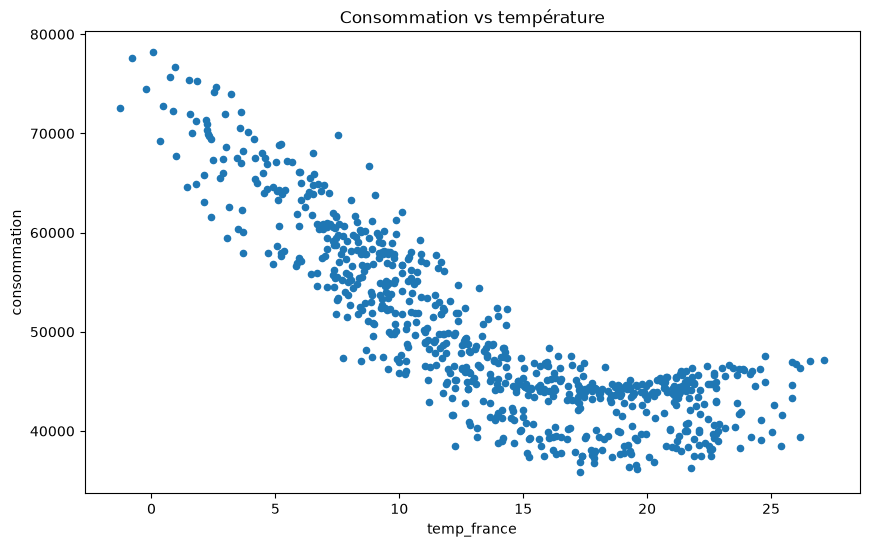

In [17]:
df_jour.plot(kind="scatter", x="temp_france", y="consommation", figsize=(10, 6), title="Consommation vs température")

On remarque une certaine corrélation consommation-temperature, en effet, la consommation à l'air de suivre l'inverse de tendance de la température, autrement dit, lorsque la température augmenete, la consommation diminue, et inversement. On pourrait clairement lier cela au différent besoin de chauffage pendant les période froide. Notre nuage de points n'est certe pas parfaitement linéaire, mais a une allure assez proche surtout pour les temperature en dessous de 18 degrés, alors que au dessus la courbe a tendance à s'applatire, avec une legere augmentation de la consommation vers la pointe, on pourra expliquer cela par l'utilisation de la clim pendant les canicules.

In [18]:
df_froid=df_jour[df_jour['temp_france']<15]

On choisi de filtrer les jours froids pour appliquer une régression sur la partie à l'allure la plus linéaire.

In [19]:
from scipy.stats import linregress
resultat = linregress(df_froid["temp_france"], df_froid["consommation"])

In [20]:
resultat

LinregressResult(slope=np.float64(-2066.1591722850276), intercept=np.float64(73958.75004355595), rvalue=np.float64(-0.8882864755679162), pvalue=np.float64(4.86565134230748e-146), stderr=np.float64(51.75981842757125), intercept_stderr=np.float64(509.0822135498369))

In [21]:
resultat.rvalue**2

np.float64(0.7890528626768701)

La pente vaut -2066 MW/C, autrement dit, pour chaque degrés ajoutée pour une temperature inférieur a 15 degres, la consommation diminue de 2066 MW, ce qui est logique vu que la courbe est décroissante, et confirme notre hypothèse sur le chauffage, plus la temperature augmente moins on a besoin de chauffer, donc on consomme moins, RTE communique une thermosensibilité d'environ 2 400 MW/°C à la pointe hivernale ; notre estimation sur moyennes journalières (2 066 MW/°C) est cohérente, l'écart s'expliquant par le lissage journalier qui atténue les pointes. Notre R^2 vaut 0.79 ce qui montre que 79% des variations journalières de consommation sont expliquées par la seule température sur ce domaine sur notre plage froide (les températures inférieures à 15 degrés).

In [22]:
df_froid["prediction"] = resultat.slope * df_froid["temp_france"] + resultat.intercept

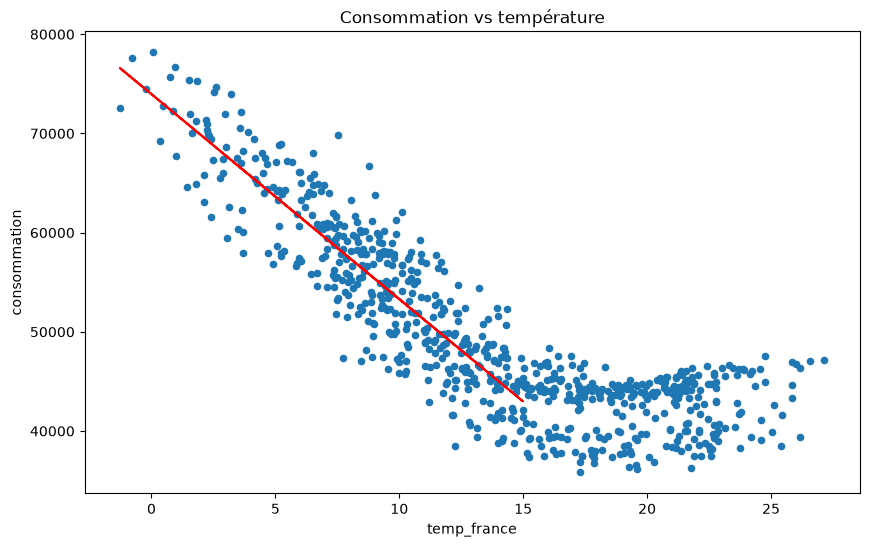

In [23]:
import matplotlib.pyplot as plt

df_jour.plot(kind="scatter", x="temp_france", y="consommation", figsize=(10, 6), title="Consommation vs température")
plt.plot(df_froid["temp_france"], df_froid["prediction"], color="red")